# Value-Momentum-Everywhere — a quantitative teardown 🔬
### Four sleeves x two signals x one recipe · HAC t's on the global combo · the diversification-arithmetic decomposition · a 50-seed random-rank placebo · costs x turnover · a planted-effect synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Just_diversification_arithmetic%3F: Confirmed](https://img.shields.io/badge/Just_diversification_arithmetic%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Asness–Moskowitz–Pedersen (2013) claim (i) value and momentum premia in every asset class, (ii) negative VAL–MOM correlation everywhere, (iii) a 50/50 combo that dominates either leg. We rebuild all three on free data with one uniform construction and judge with autocorrelation-robust statistics.

> ⚠️ **Data notes.** EQ = 13 country ETFs, total-return, *survivors* (named on the Signal axis); FX = G10 **spot** (price-only, no carry); BOND/CMD = Yahoo continuous front-month futures daily returns (roll noise, ±25% clip — the shared cache built by [study 31](../../31-trade-winds/)). As-of **2026-05-31** (June 2026 partial, dropped). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `2cd41e1339cb`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from value_momentum_everywhere import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANELS = data.load_sleeves()
    SLEEVES = {k: st.sleeve_series(v) for k, v in PANELS.items()}
else:
    PANELS = SLEEVES = None
print("real sleeve cache present:", HAVE_REAL)

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-05-31', 'fingerprint': '2cd41e1339cb', 'sleeves': [('EQ', 13, -0.25, -1.35, -0.01, -0.06, -0.16, -0.73, -0.16, 349, '1997-05'), ('FX', 9, 0.1, 0.46, -0.01, -0.07, 0.04, 0.2, -0.03, 270, '2002-09'), ('BOND', 3, -0.22, -1.19, -0.19, -0.97, -0.36, -1.63, -0.11, 203, '2001-11'), ('CMD', 8, 0.14, 0.67, -0.32, -1.72, -0.15, -0.86, 0.17, 296, '2001-10')], 'mean_rho': -0.03, 'glob': {'val': (0.01, 0.03, 0.4, 248), 'mom': (-0.38, -1.95, -28.0, 296), 'combo': (-0.29, -1.49, -15.7, 296)}, 'sub_pre': (-0.5, -1.64, 123), 'sub_post': (-0.13, -0.54, 174), 'rho_global': 0.145, 'pred_sr': -0.267, 'real_sr': -0.267, 'sr_val': 0.01, 'sr_mom': -0.41, 'placebo': {'mean_sharpe': 0.01, 'sd': 0.19, 'mean_t': 0.07, 'frac': 4, 'n_seeds': 50}, 'turnover': 0.65, 'costs': [(5.0, -1.88, -2.42, -0.37, -1.91), (10.0, -1.88, -2.81, -0.43, -2.21), (20.0, -1.88, -3.59, -0.55, -2.83)], 'robust': [('halves not thirds', -0.48, -2.4), ('mom 12-0 (no skip)', -0.34, -1.76), ('value incl. last year', -0.19, -0.88)], 'syn': [('null (no edges)', -0.04, -0.07, -0.08, -0.52, 0.03, -0.13, -0.13), ('planted VAL+MOM', 2.27, 1.49, 2.32, 14.12, 0.18, 2.51, 2.51)]}


real sleeve cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Global 50/50 combo Sharpe **-0.29**, HAC **t = -1.49** (296 months); no sleeve-leg clears \|t\| ≥ 2; the literature says real, this tape can't certify it. |
| **Tradability** | `MIRAGE` | Gross is already negative (-1.9%/yr); at 10 bps one-way + EQ borrow the net is **-2.8%/yr**. Nothing to harvest. |
| **Just diversification arithmetic?** | `CONFIRMED` | Realized combo SR **-0.267** vs two-asset-formula prediction **-0.267** — identical; the blend adds nothing beyond the formula, and the ingredients are zero. |

> 💡 In plain words: the blender works exactly as advertised — but on this tape somebody forgot to put fruit in it.

## 1 · The claim, steelmanned

For sleeve $s$ with assets $i$, month-end $t$:

$$\mathrm{VAL}_{i,t} = -\!\!\prod_{k=t-59}^{t-12}\!(1+r_{i,k}),\qquad \mathrm{MOM}_{i,t} = \prod_{k=t-11}^{t-1}(1+r_{i,k})$$

(the 5-year reversal skipping the momentum year — AMP's own non-stock value proxy — and the classic 12-1). Long the top third, short the bottom third, equal weight, hold month $t{+}1$ (the ONE execution lag). The combo averages the *weights* 50/50; the global portfolio averages live sleeves equally.

- **H₁ (everywhere).** Each sleeve's VAL and MOM Sharpe > 0.
- **H₂ (the hedge).** corr(VAL, MOM) strongly negative (~−0.5) within sleeves.
- **H₃ (the free lunch).** The global 50/50 combo clears HAC *t* ≥ 2.

We find **H₁ rejected on this tape** (all eight legs statistical zero), **H₂ mostly absent** (mean ρ ≈ 0), **H₃ rejected** (combo *t* negative). The verdict grades what the tape says, not what the literature deserves.

## 2 · So what? — what rides on each answer

The combo claim is special because it is *arithmetically guaranteed* to look good **if** the ingredients are good: for a 50/50 mix of series with Sharpes $S_v, S_m$ and correlation $\rho$ (equal vols),

$$S_{combo} \approx \frac{S_v + S_m}{\sqrt{2(1+\rho)}}.$$

With $\rho = -0.5$ that's a **1.41×** multiplier on the average ingredient — AMP's free lunch. The third axis tests whether the realized combo does anything *beyond* this formula (it must not — and does not). The null twin is [401-signal-stacking](../../401-signal-stacking/): stacked **noise** obeys the same arithmetic and delivers nothing. The new question here: stack the two most *documented* premia in finance — does the free tape supply the ingredients? Survivorship (EQ ETF panel), spot-only FX and roll-noisy futures are named where they bite.

## 3 · How we'd know — the protocol

- **Sleeves.** EQ: 13 country ETFs (total-return, 1996→, survivors). FX: 9 G10 pairs vs USD (spot, price-only). BOND: ZF/ZN/ZB futures (excess). CMD: 8 commodity futures (excess). Monthly, as-of 2026-05-31.
- **Signals.** VAL = 5y reversal (months t-59..t-12); MOM = 12-1 (t-11..t-1); complete windows required; computed from data through month-end *t* only.
- **Books.** Top/bottom thirds, equal-weight, 100/100 (gross 2× NAV), rebalanced monthly, held month t+1 — **one** execution lag, documented.
- **Inference.** HAC/Newey–West t's (Bartlett, automatic lag) on every monthly series; Sharpe races excess-vs-excess (L/S is self-financing; futures returns are excess).
- **Placebo.** Random-rank signals through the identical pipeline, averaged over **50 seeds** (house rule ≥ 20).
- **Costs.** One-way bps × traded notional; the EQ short leg pays 50 bps/yr borrow; 5/10/20 bps scenarios.
- **Splits & variants.** Pre/post-2012 (AMP's sample ends 2011 — a justified, non-snooped split); halves-not-thirds; 12-0 momentum; value including the last year.
- **Control.** A 4-sleeve synthetic world with plantable VAL/MOM edges: the zero-edge null must stay flat, planted edges must light up and obey the diversification formula.

## 4 · The teardown

### 4a · Eight legs, four sleeves — the ingredient matrix

Per-sleeve Sharpe and HAC *t* for VAL, MOM, COMBO, plus the VAL–MOM correlation.

sleeve  VAL SR      t  MOM SR      t   COMBO      t    rho    n
EQ       -0.25  -1.35   -0.01  -0.06   -0.16  -0.73  -0.16  349
FX       +0.10  +0.46   -0.01  -0.07   +0.04  +0.20  -0.03  270
BOND     -0.22  -1.19   -0.19  -0.97   -0.36  -1.63  -0.11  203
CMD      +0.14  +0.67   -0.32  -1.72   -0.15  -0.86  +0.17  296


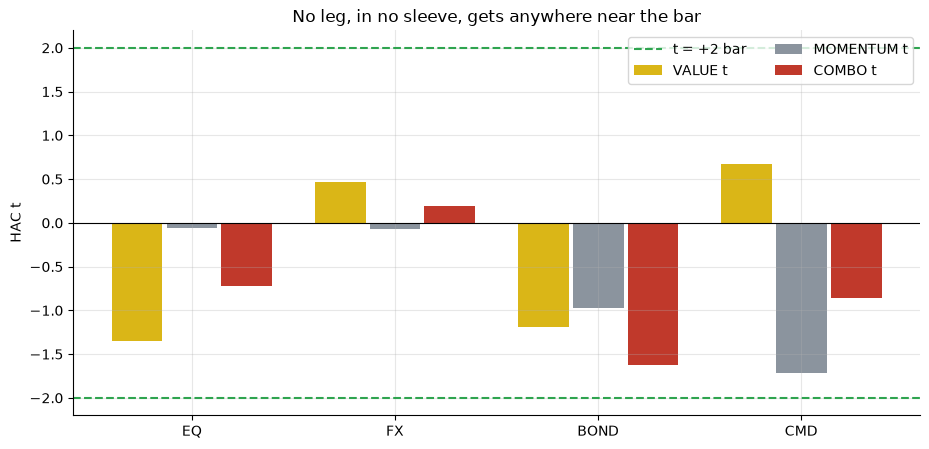

In [2]:
names = [s[0] for s in R['sleeves']]
if HAVE_REAL:
    stats = {k: st.sleeve_stats(SLEEVES[k]) for k in names}
    rows = [(k, stats[k]['val']['sharpe'], stats[k]['val']['t'],
             stats[k]['mom']['sharpe'], stats[k]['mom']['t'],
             stats[k]['combo']['sharpe'], stats[k]['combo']['t'],
             stats[k]['rho'], stats[k]['n']) for k in names]
else:
    rows = [(s[0], s[2], s[3], s[4], s[5], s[6], s[7], s[8], s[9]) for s in R['sleeves']]
print(f"{'sleeve':6s} {'VAL SR':>7s} {'t':>6s} {'MOM SR':>7s} {'t':>6s} "
      f"{'COMBO':>7s} {'t':>6s} {'rho':>6s} {'n':>4s}")
for r in rows:
    print(f'{r[0]:6s} {r[1]:+7.2f} {r[2]:+6.2f} {r[3]:+7.2f} {r[4]:+6.2f} '
          f'{r[5]:+7.2f} {r[6]:+6.2f} {r[7]:+6.2f} {r[8]:4d}')
fig, ax = plt.subplots(figsize=(9.4, 4.6))
x = np.arange(len(rows))
ax.bar(x-0.27, [r[2] for r in rows], 0.25, color=AMBER, label='VALUE t')
ax.bar(x,      [r[4] for r in rows], 0.25, color=GREY, label='MOMENTUM t')
ax.bar(x+0.27, [r[6] for r in rows], 0.25, color=RED, label='COMBO t')
ax.axhline(2, ls='--', c=GREEN, label='t = +2 bar'); ax.axhline(-2, ls='--', c=GREEN)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylabel('HAC t')
ax.set_title('No leg, in no sleeve, gets anywhere near the bar')
ax.legend(ncol=2); plt.tight_layout(); plt.show()

> 💡 In plain words: the paper needs every bar clearly above the green line. The best we find anywhere is \|t\| < 2, and half the legs point the *wrong way* — commodity momentum is the worst (t = -1.72). The everywhere-premia are simply not on this tape.

The hedge (H₂) fares no better: mean per-sleeve ρ(VAL, MOM) = **-0.03** vs the paper's ~−0.5.

### 4b · The claim under test — the global 50/50 combo

Equal-weight the live sleeves into global VAL / MOM / COMBO and put a HAC t on each.

GLOBAL VAL   : SR +0.01   HAC t +0.03   +0.4 bps/mo   n=248
GLOBAL MOM   : SR -0.38   HAC t -1.95   -28.0 bps/mo   n=296
GLOBAL COMBO : SR -0.29   HAC t -1.49   -15.7 bps/mo   n=296


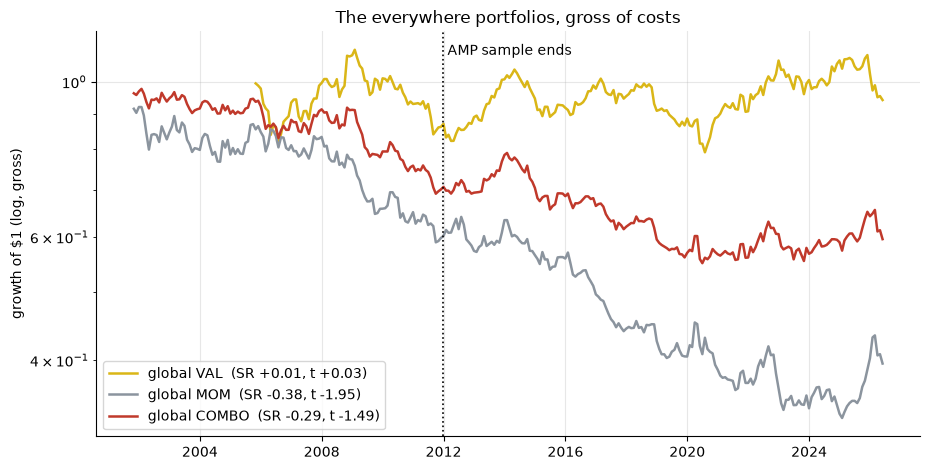

In [3]:
if HAVE_REAL:
    G = {leg: st.global_series(SLEEVES, leg) for leg in ('val','mom','combo')}
    tbl = {leg: (st.sharpe(G[leg]), st.hac_mean(G[leg])['t'],
                 st.hac_mean(G[leg])['mean_bps'], len(G[leg])) for leg in G}
else:
    tbl = R['glob']
for leg, v in tbl.items():
    print(f'GLOBAL {leg.upper():6s}: SR {v[0]:+.2f}   HAC t {v[1]:+.2f}   '
          f'{v[2]:+.1f} bps/mo   n={v[3]}')
if HAVE_REAL:
    fig, ax = plt.subplots(figsize=(9.4, 4.8))
    for leg, cname in (('val', AMBER), ('mom', GREY), ('combo', RED)):
        s = G[leg]
        ax.plot((1+s).cumprod(), color=cname, lw=1.8,
                label=f'global {leg.upper()}  (SR {st.sharpe(s):+.2f}, t {st.hac_mean(s)["t"]:+.2f})')
    ax.axvline(pd.Timestamp('2011-12-31'), ls=':', c='k', lw=1.2)
    ax.annotate(' AMP sample ends', (pd.Timestamp('2011-12-31'), ax.get_ylim()[1]*0.95))
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log, gross)')
    ax.set_title('The everywhere portfolios, gross of costs')
    ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: the headline claim — a strong, significant global combo — lands at **SR -0.29, t = -1.49**. Sub-periods: ≤2011 (overlapping AMP's sample) SR **-0.50** (t = -1.64, n = 123); ≥2012 SR **-0.13** (t = -0.54, n = 174). Neither half clears anything — and the AMP-overlap half is actually the *worse* one, so this is not even a clean "decay" story: the combo was never visible on this free tape.

### 4c · The third axis — diversification arithmetic, nothing more

Two-asset formula: predicted combo Sharpe from (μ, σ, ρ) of the global VAL and MOM legs vs the realized Sharpe of the 50/50 mix of the same two series.

global rho(VAL,MOM) = +0.145
ingredients: SR_val +0.006   SR_mom -0.408
predicted combo SR (formula) = -0.267
realized  combo SR           = -0.267
gap = 0.0000  -> pure arithmetic


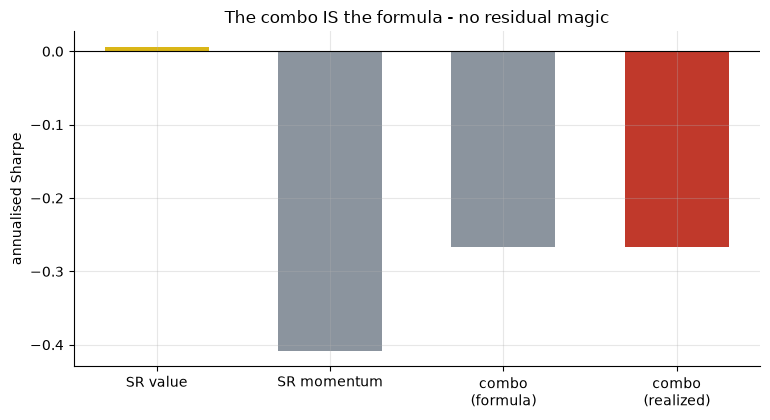

In [4]:
if HAVE_REAL:
    dc = st.diversification_check(st.global_series(SLEEVES,'val'),
                                  st.global_series(SLEEVES,'mom'))
else:
    dc = dict(rho=R['rho_global'], predicted=R['pred_sr'], realized=R['real_sr'],
              sr_val=R['sr_val'], sr_mom=R['sr_mom'])
print(f"global rho(VAL,MOM) = {dc['rho']:+.3f}")
print(f"ingredients: SR_val {dc['sr_val']:+.3f}   SR_mom {dc['sr_mom']:+.3f}")
print(f"predicted combo SR (formula) = {dc['predicted']:+.3f}")
print(f"realized  combo SR           = {dc['realized']:+.3f}")
print(f"gap = {abs(dc['realized']-dc['predicted']):.4f}  -> pure arithmetic")
fig, ax = plt.subplots(figsize=(7.8, 4.3))
ax.bar(['SR value','SR momentum','combo\n(formula)','combo\n(realized)'],
       [dc['sr_val'], dc['sr_mom'], dc['predicted'], dc['realized']],
       color=[AMBER, GREY, GREY, RED], width=.6)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('annualised Sharpe'); ax.set_title('The combo IS the formula - no residual magic')
plt.tight_layout(); plt.show()

> 💡 In plain words: realized **-0.267** vs predicted **-0.267** — the combo does *exactly* what two-asset arithmetic says, no more. That is the honest content of "everywhere": diversification is real, but it **multiplies the ingredients** — in [401](../../401-signal-stacking/) the ingredients were noise; here they are two famous premia that this tape pays at ≈ 0. Zero times 1.41 is still zero.

### 4d · Placebo — random ranks through the identical pipeline (50 seeds)

If the construction (thirds, lag, sleeve-averaging) baked in any drift, random signals would show it.

In [5]:
# canonical numbers from the frozen run (50 seeds is minutes of compute);
# recompute with st.random_placebo(PANELS) if you want to reproduce live
pl = R['placebo']
print(f"random-rank global combo, {pl['n_seeds']} seeds: mean SR {pl['mean_sharpe']:+.2f} "
      f"(sd {pl['sd']:.2f}), mean HAC t {pl['mean_t']:+.2f}, frac |t|>=2 = {pl['frac']:.0f}%")
print(f"observed real-signal combo SR {R['glob']['combo'][0]:+.2f} sits inside the noise band")

random-rank global combo, 50 seeds: mean SR +0.01 (sd 0.19), mean HAC t +0.07, frac |t|>=2 = 4%
observed real-signal combo SR -0.29 sits inside the noise band


> 💡 In plain words: noise portfolios built the same way average SR **+0.01** — the machine is unbiased, and the real-signal combo (**-0.29**) sits *inside* the noise band, on the wrong side.

### 4e · Costs and robustness — it only gets worse

One-way costs × traded notional (avg combo turnover ≈ 0.65× NAV/month), EQ short leg pays 50 bps/yr borrow; then the construction variants.

In [6]:
print('costs (global combo):')
for cb, g, n, sr, t in R['costs']:
    print(f'  {cb:>4.0f} bps one-way: gross {g:+.1f}%/yr -> net {n:+.1f}%/yr   '
          f'net SR {sr:+.2f}   net t {t:+.2f}')
print()
print('construction variants (global combo, gross):')
for v, sr, t in R['robust']:
    print(f'  {v:24s}: SR {sr:+.2f}   HAC t {t:+.2f}')

costs (global combo):
     5 bps one-way: gross -1.9%/yr -> net -2.4%/yr   net SR -0.37   net t -1.91
    10 bps one-way: gross -1.9%/yr -> net -2.8%/yr   net SR -0.43   net t -2.21
    20 bps one-way: gross -1.9%/yr -> net -3.6%/yr   net SR -0.55   net t -2.83

construction variants (global combo, gross):
  halves not thirds       : SR -0.48   HAC t -2.40
  mom 12-0 (no skip)      : SR -0.34   HAC t -1.76
  value incl. last year   : SR -0.19   HAC t -0.88


> 💡 In plain words: gross **-1.9%/yr** becomes **-3.6%/yr** at 20 bps. Halves instead of thirds, momentum without the skip-month, value including the last year — every variant stays negative-to-flat. There is no construction under which this tape pays the combo.

### 4f · Synthetic control — the machinery can see the effect when it exists

A 4-sleeve world generated month-by-month with plantable cross-sectional value and momentum edges. Zero edges → the pipeline must report nothing. Planted edges → both legs light up AND the combo obeys the same diversification formula.

In [7]:
rows = []
for ve, me, label in ((0.0, 0.0, 'null (no edges)'), (0.004, 0.004, 'planted edges')):
    world = data.synthetic_world(val_edge=ve, mom_edge=me, seed=638)
    ssl = {k: st.sleeve_series(v) for k, v in world.items()}
    gv, gm = st.global_series(ssl,'val'), st.global_series(ssl,'mom')
    gc = st.global_series(ssl,'combo')
    dc = st.diversification_check(gv, gm)
    rows.append((label, st.sharpe(gv), st.sharpe(gm), st.sharpe(gc),
                 st.hac_mean(gc)['t'], dc['predicted'], dc['realized']))
for r in rows:
    print(f'{r[0]:18s}: VAL SR {r[1]:+.2f}  MOM SR {r[2]:+.2f}  COMBO SR {r[3]:+.2f} '
          f'(t {r[4]:+.2f})   formula {r[5]:+.2f} vs realized {r[6]:+.2f}')

null (no edges)   : VAL SR -0.04  MOM SR -0.07  COMBO SR -0.08 (t -0.52)   formula -0.13 vs realized -0.13
planted edges     : VAL SR +2.27  MOM SR +1.49  COMBO SR +2.32 (t +14.12)   formula +2.51 vs realized +2.51


> 💡 In plain words: with nothing planted the pipeline reports SR ≈ **-0.08** (it cannot hallucinate a free lunch); with modest planted edges it reports **+2.32** (t = +14.1) and the combo again equals the formula. The machine works — the real tape simply has nothing for it to find. *(A machinery proof only — never cited in support of a stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — the literature (AMP 2013, 1972–2011) says the premia are real; this free tape cannot certify any of it: all eight sleeve-legs at \|t\| < 2, global combo SR **-0.29** with HAC **t = -1.49** (296 months), hedge correlation ≈ 0, and neither the ≤2011 nor the ≥2012 half shows anything. Survivor ETFs, spot FX and roll-noisy futures are named — they blur, but they cannot manufacture a premium that isn't there.
- **Tradability `MIRAGE`** — negative gross (-1.9%/yr), ~0.65× NAV monthly turnover, and costs push it to **-2.8%/yr** at 10 bps. Nothing to deploy.
- **Just diversification arithmetic? `CONFIRMED`** — realized combo SR **-0.267** = formula **-0.267**. The "free lunch" is the two-asset formula, which multiplies its ingredients — real ones in AMP's sample, absent ones here, noise in [401](../../401-signal-stacking/).

## 6 · Going further

- **What would change the verdict.** AMP's own tape: dozens of markets per class, point-in-time universes, proper futures rolls, fundamental value measures (B/M, real yield differentials), 1972→. If someone rebuilds that from free sources and a leg clears HAC t ≥ 2, the Signal axis reopens.
- **The individual pieces already died separately on this desk** — FX momentum ([147](../../147-fx-momentum/)), stock long-term reversal ([196](../../196-long-term-reversal/)), FX carry ([364](../../364-fx-carry-trade/)), time-series momentum ([31](../../31-trade-winds/), Weak). A combo of Weak-to-None ingredients grading Weak is exactly what the arithmetic predicts.
- **The blender is still worth owning.** ρ ≈ 0 between strategy legs *does* cut risk — diversification survives every audit on this desk. What doesn't survive is the promise that the ingredients are premia rather than noise.

*The reproducible core is offline and deterministic; every number above is printed by [`examples/verify.py`](../examples/verify.py). Sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*